In [1]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, RepeatedKFold
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import LinearRegression


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [2]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", StandardScaler()),
        (step_name, model)
    ])

In [3]:
pl_linear = make_pipeline(LinearRegression(), "predict")

In [ ]:
df = pd.read_csv("data/processed_dataset_wo_metals_w_more_qm.csv")

df = df.drop("avg_atomic_quadrupole_principal_invariant_3", axis=1)
df = df.drop("min_atomic_quadrupole_principal_invariant_3", axis=1)
df = df.drop("max_atomic_quadrupole_principal_invariant_3", axis=1)
df = df.drop("min_overlap_integral", axis=1)

df = df.drop(197)

y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [42]:
X_trans = pl_linear[:-1].fit_transform(X)
X_trans_df = pd.DataFrame(
    X_trans,
    columns=pl_linear[:-1].get_feature_names_out()    
)

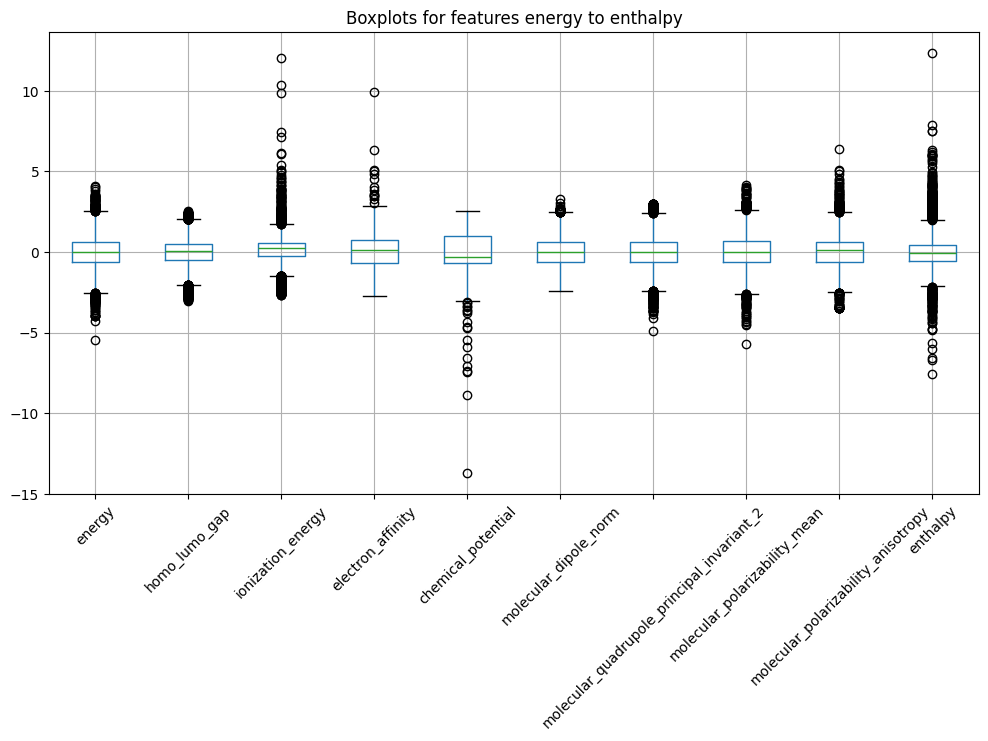

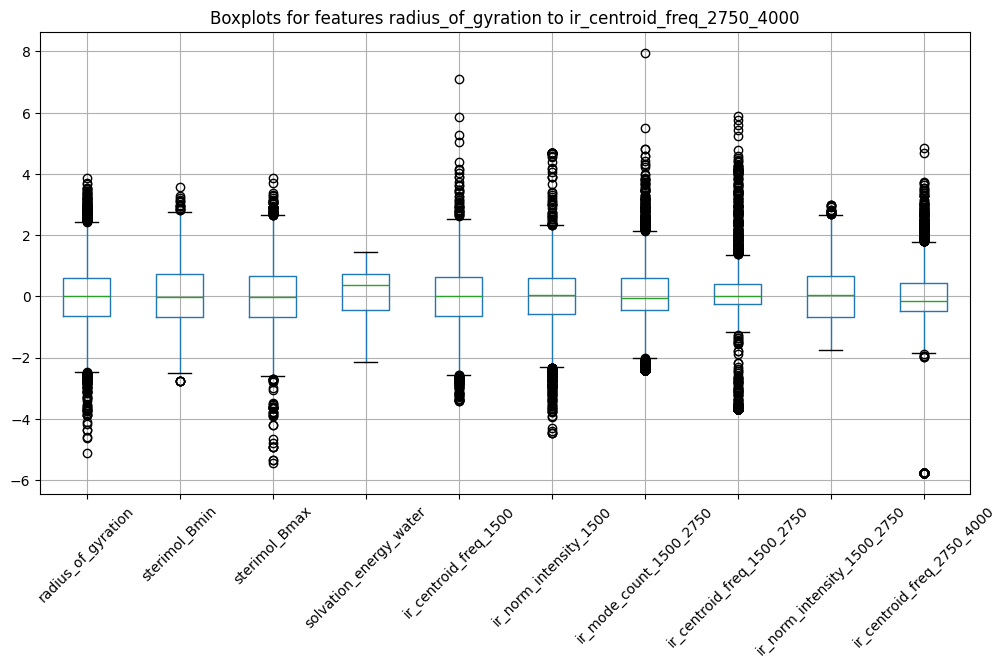

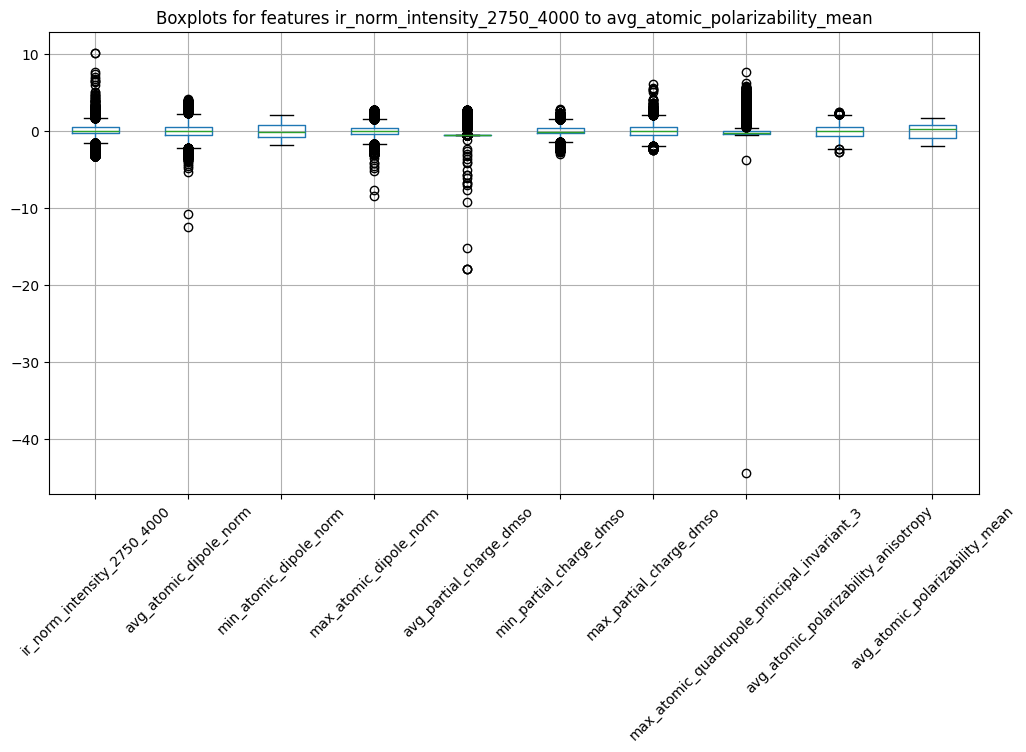

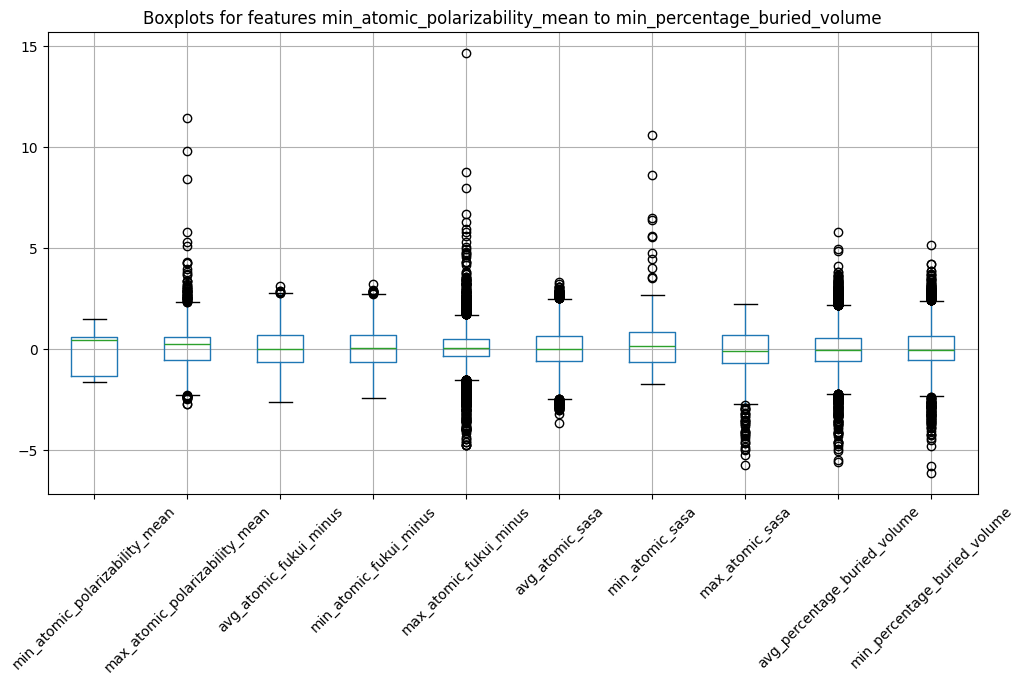

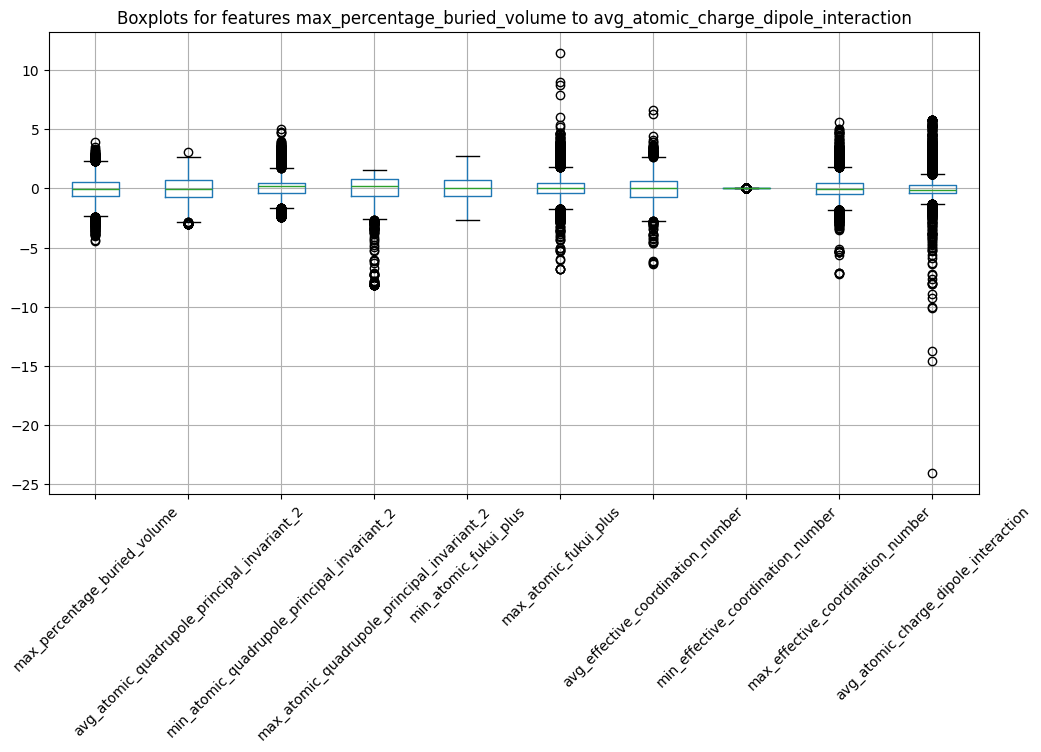

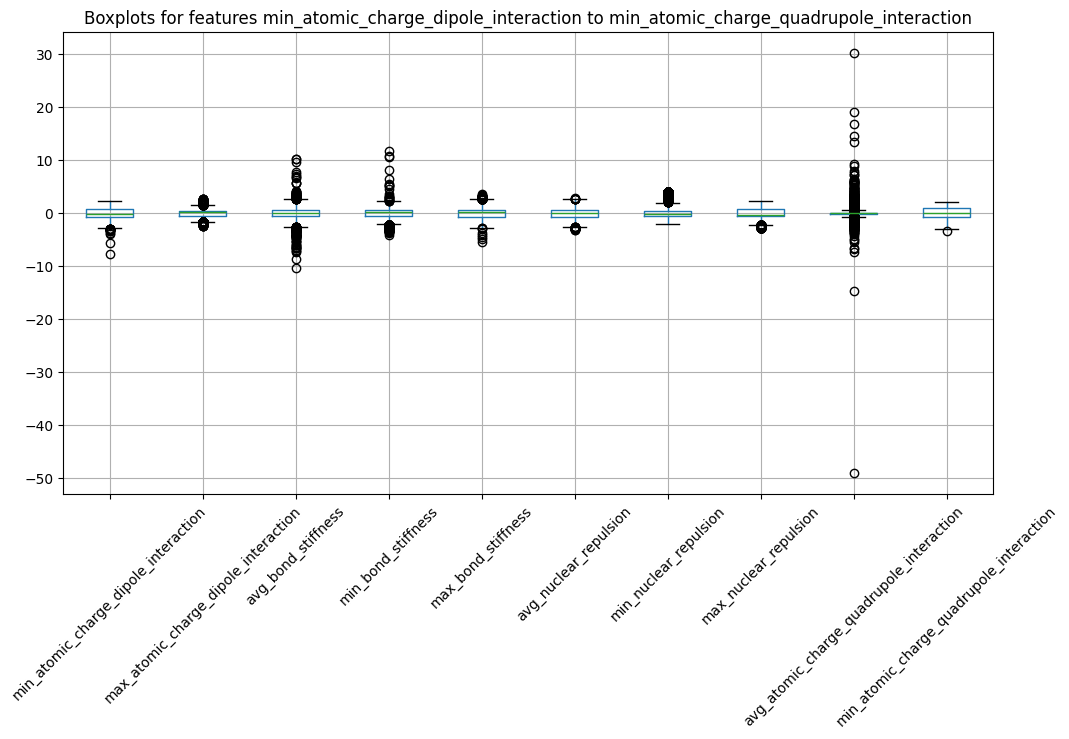

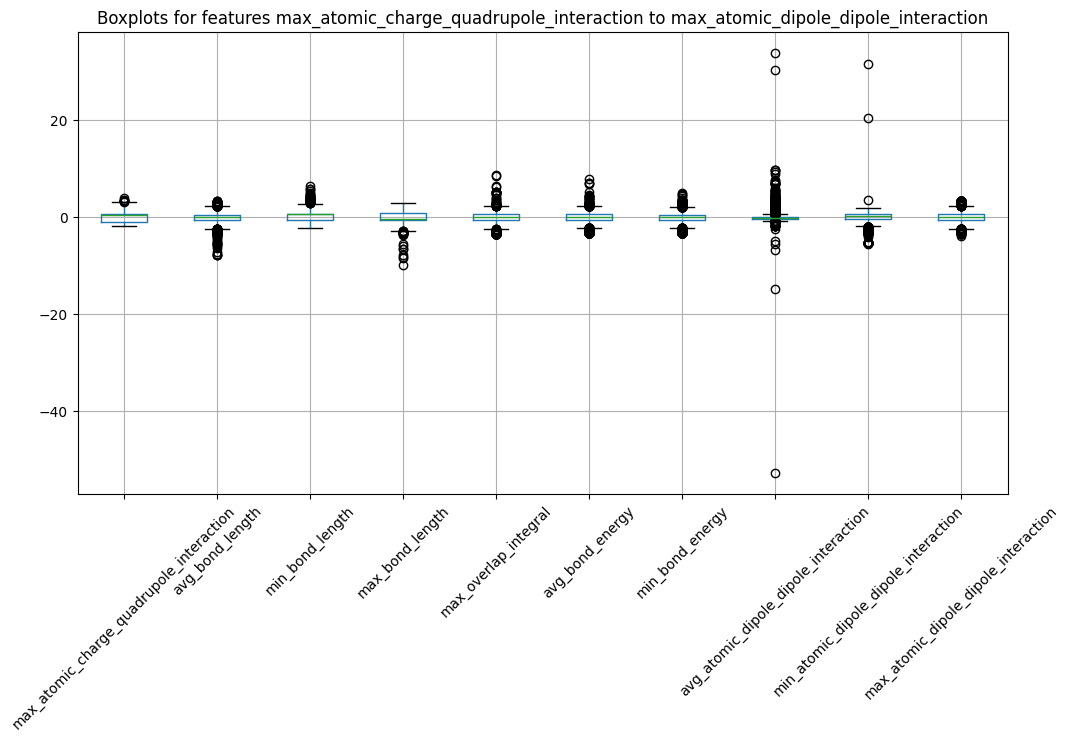

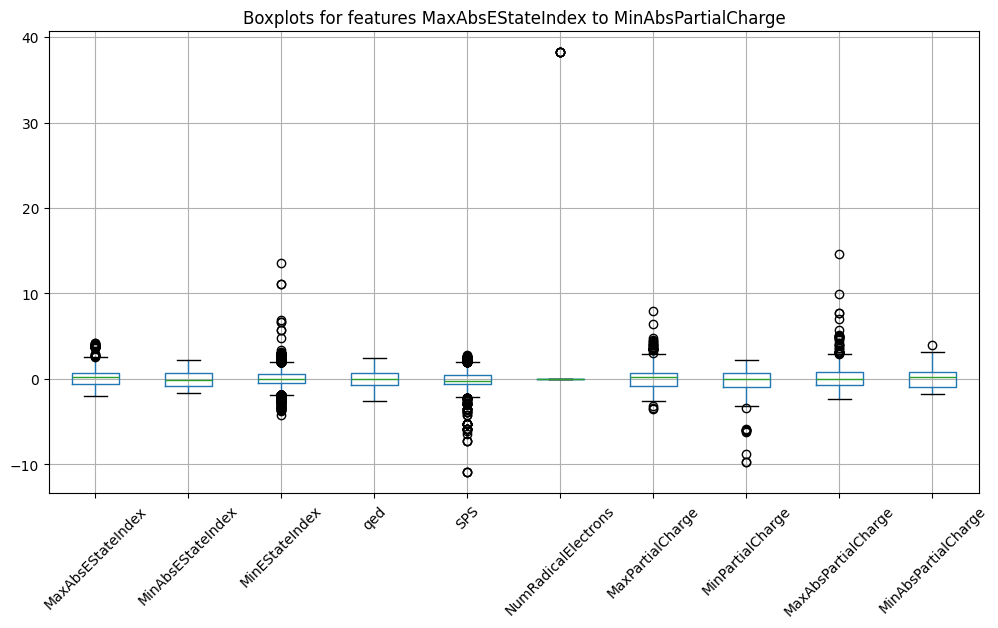

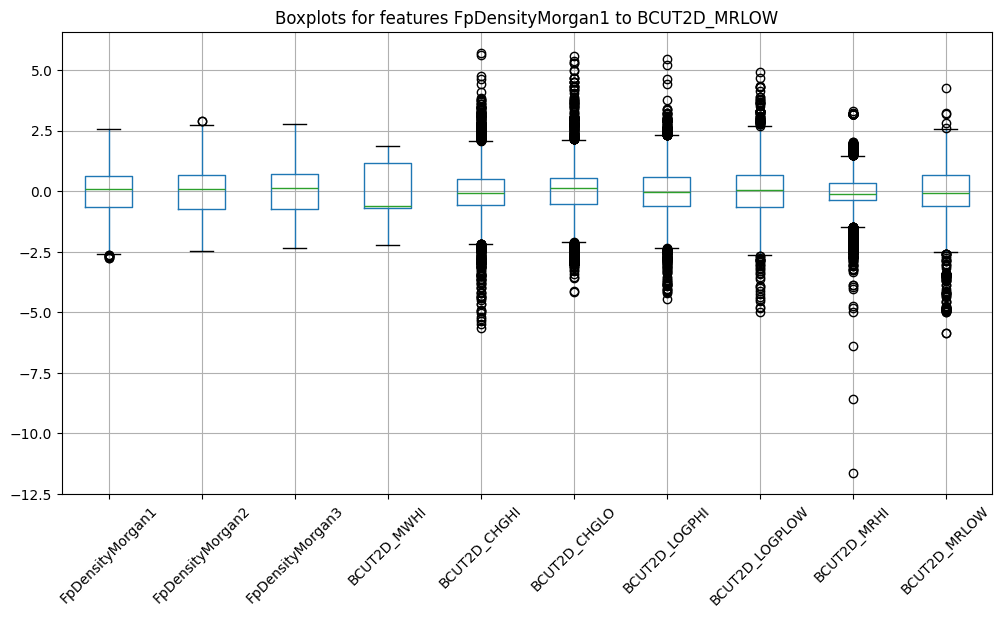

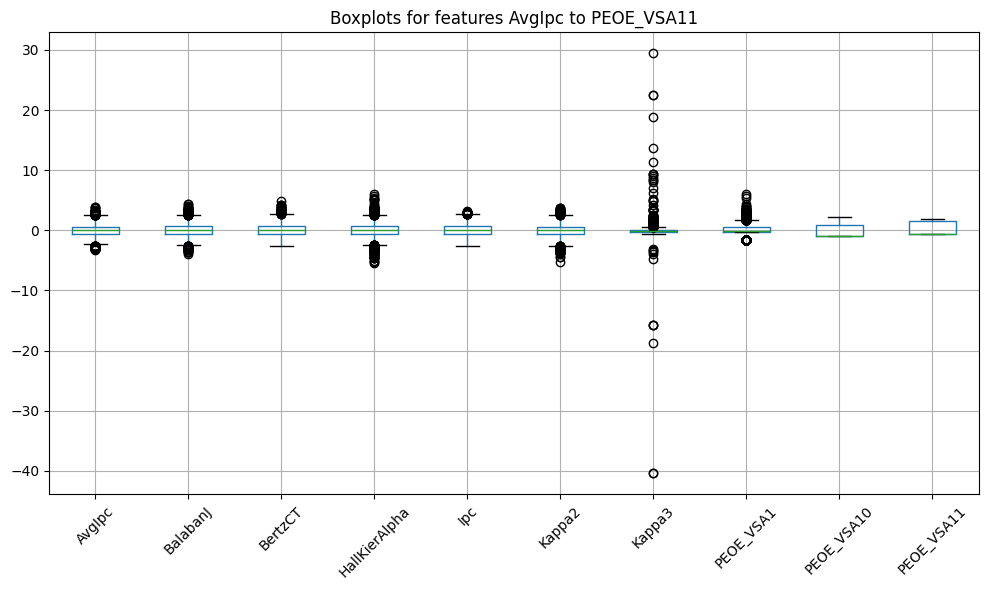

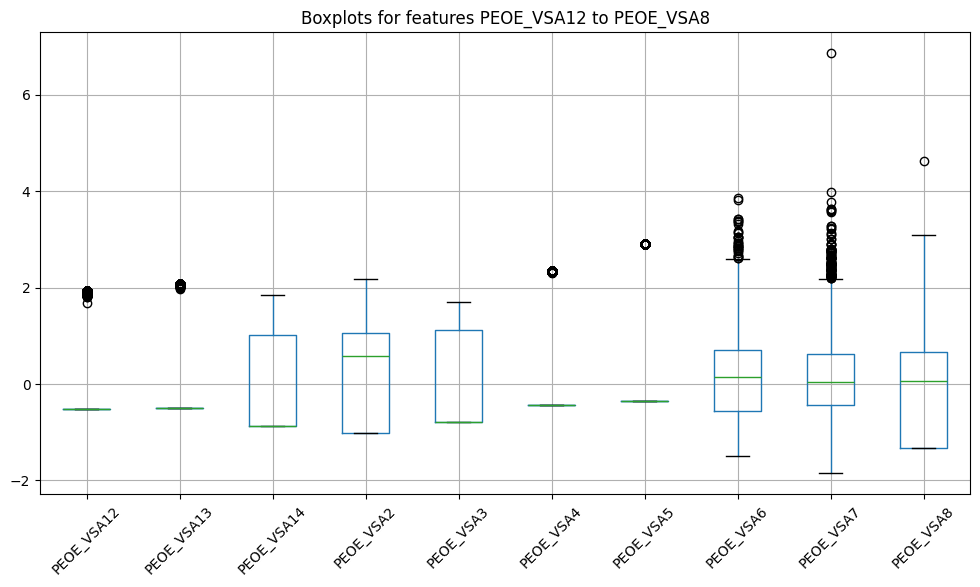

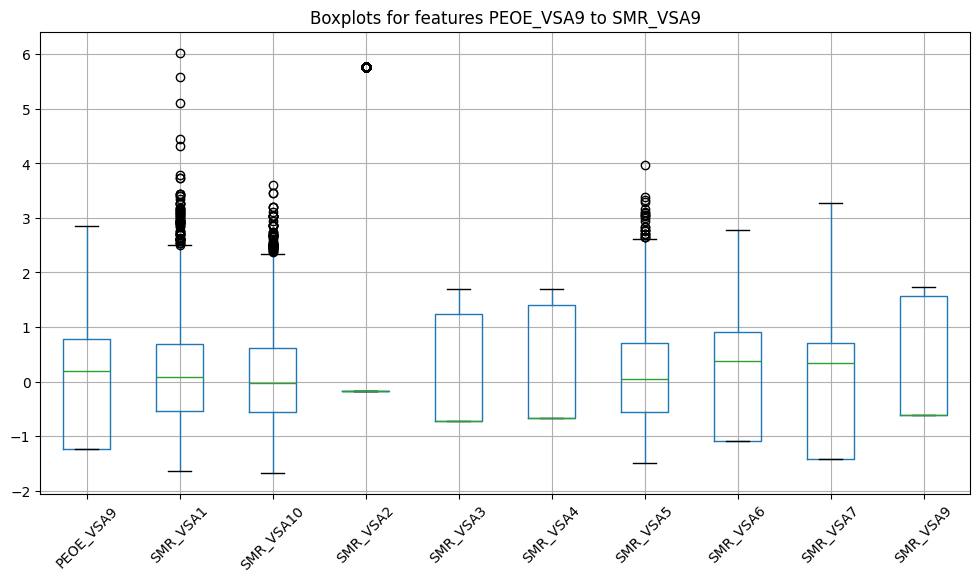

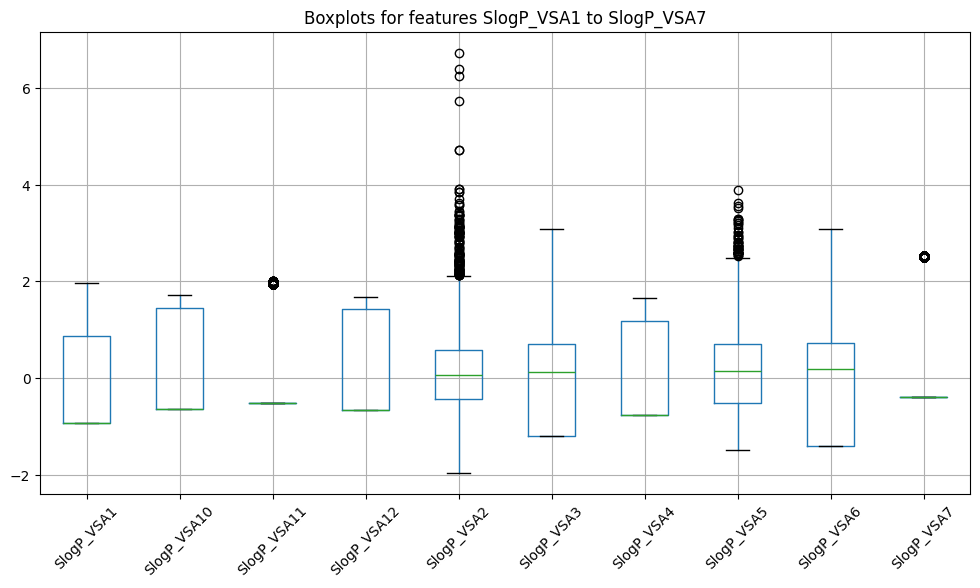

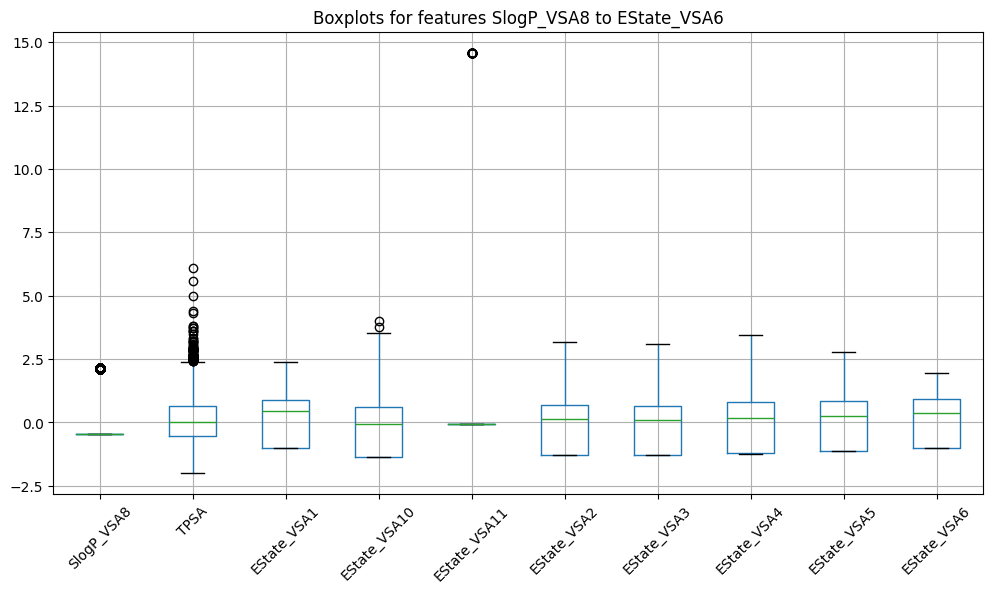

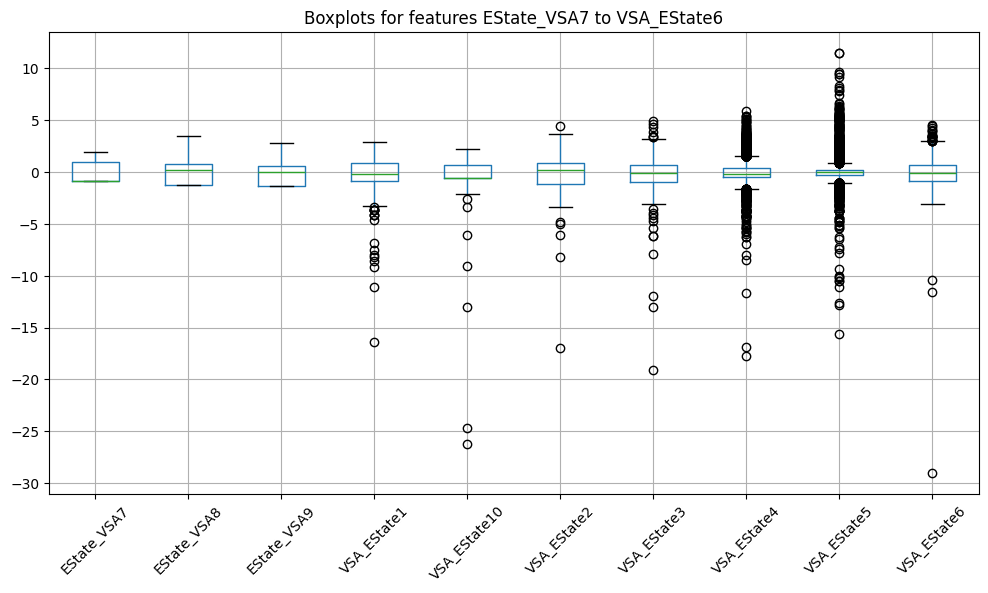

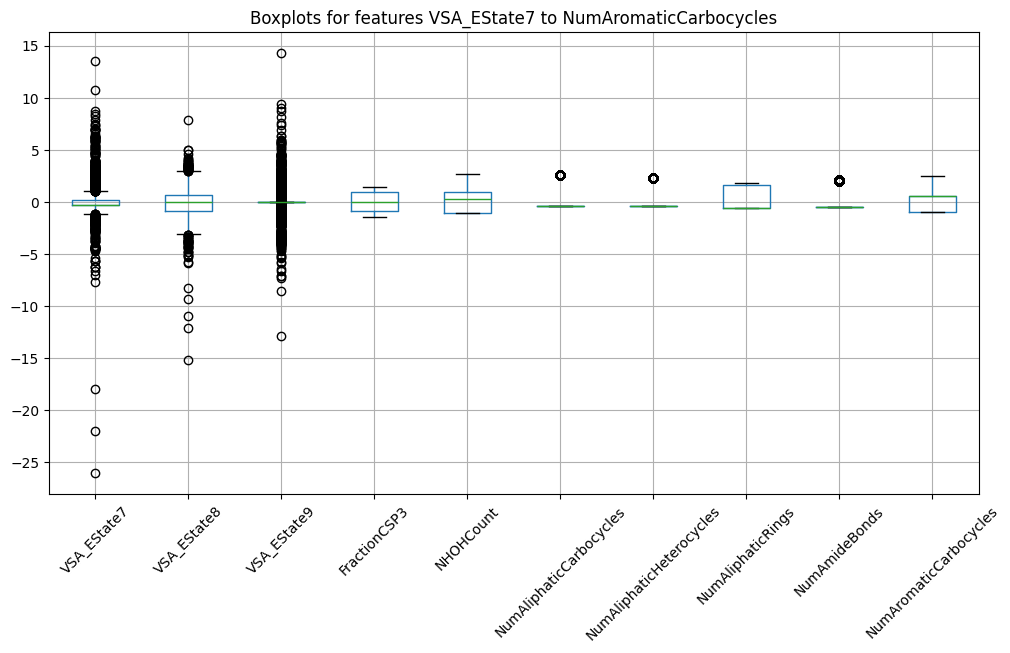

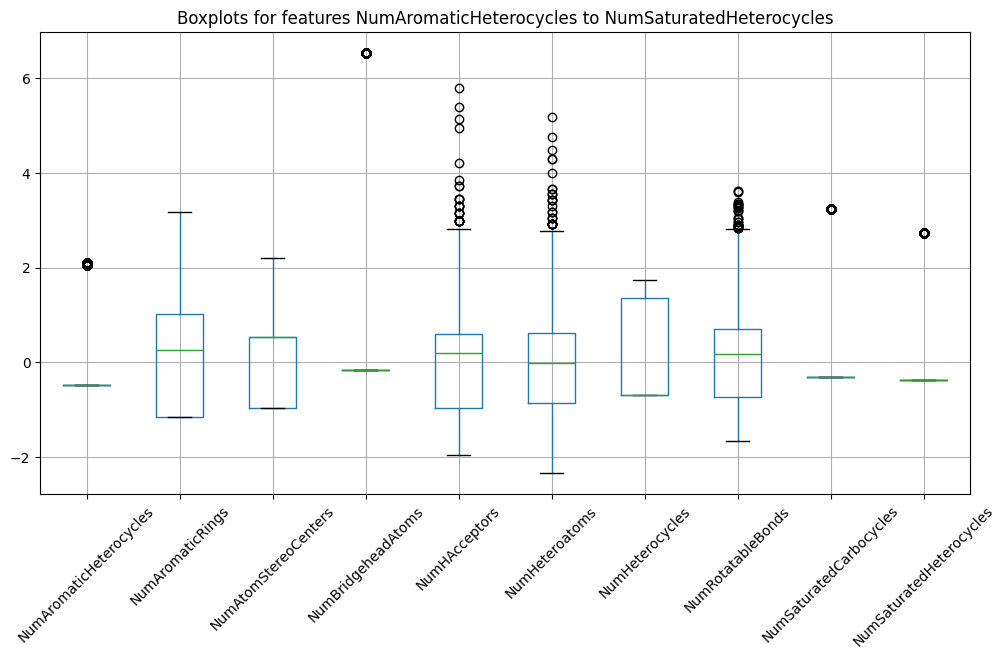

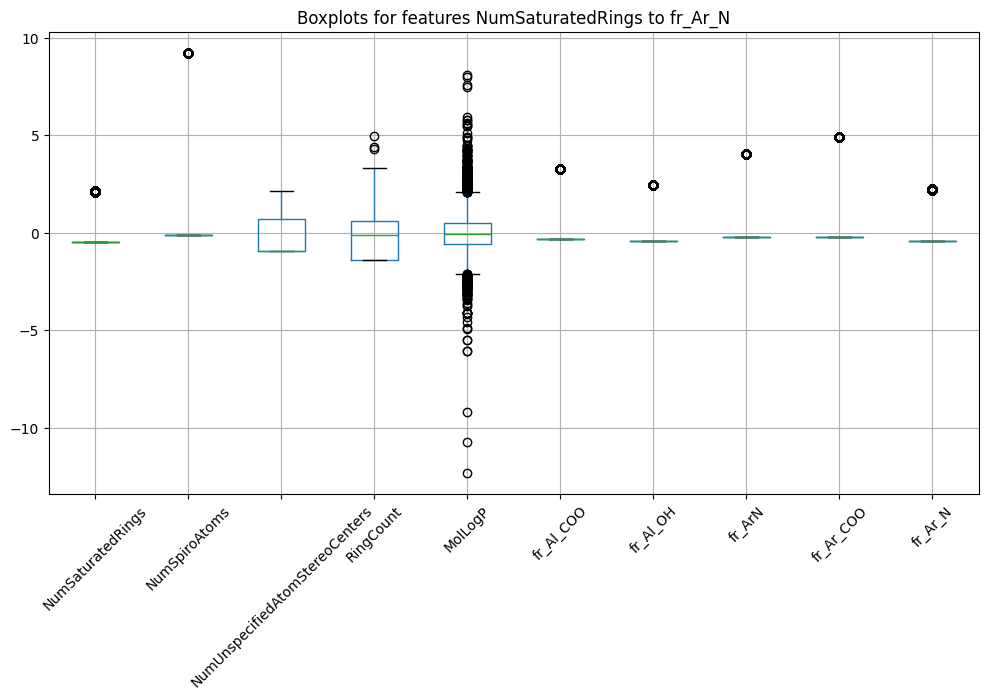

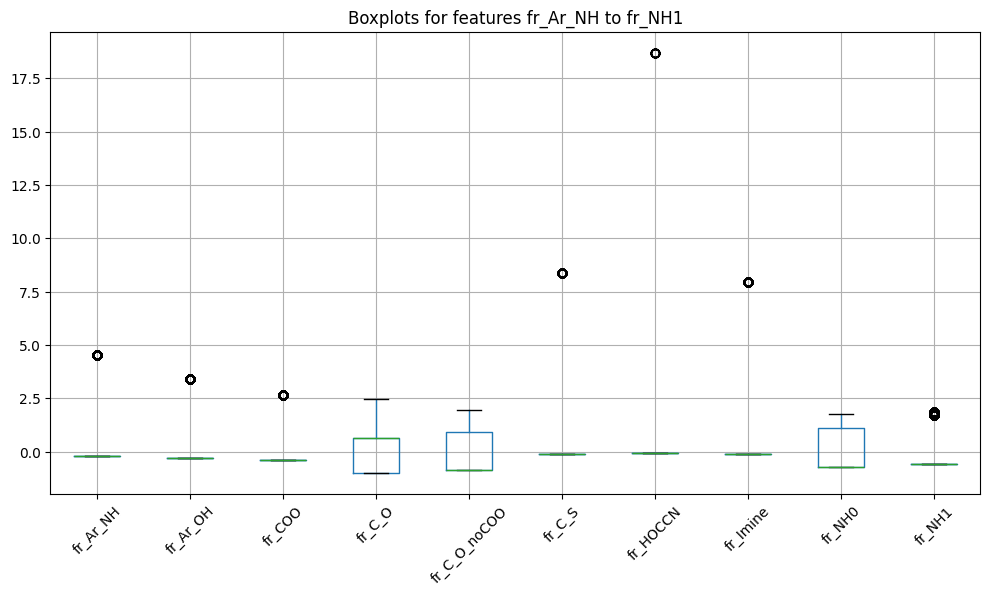

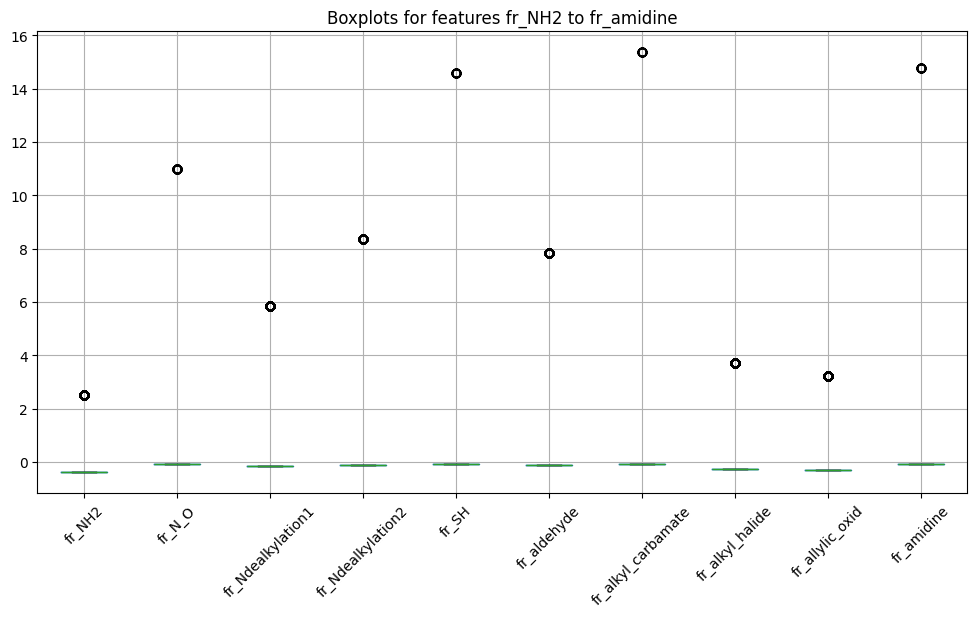

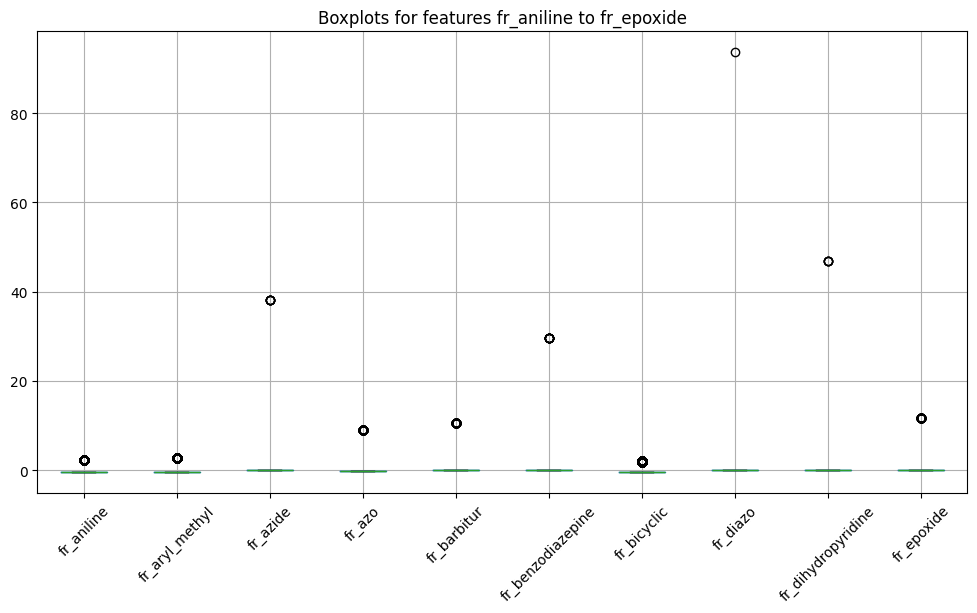

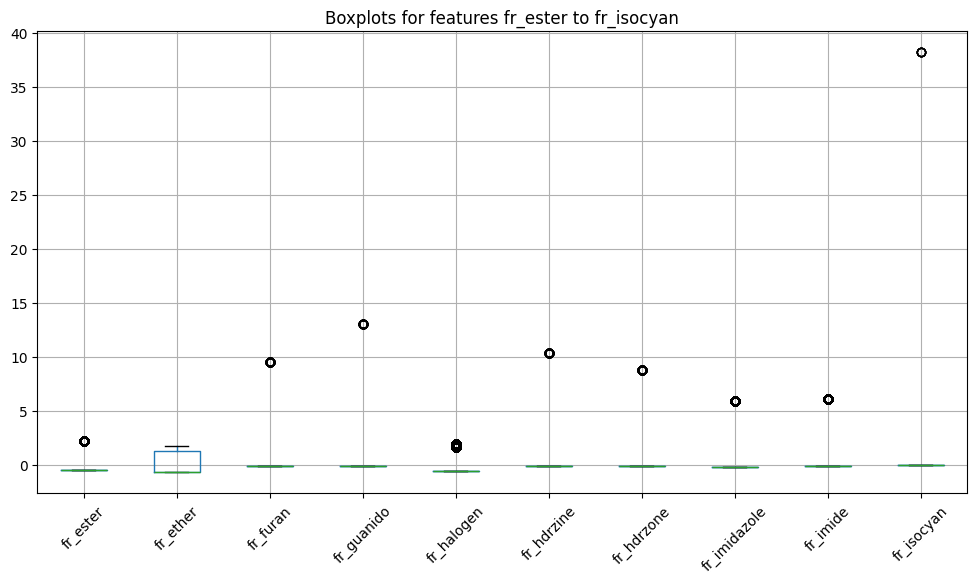

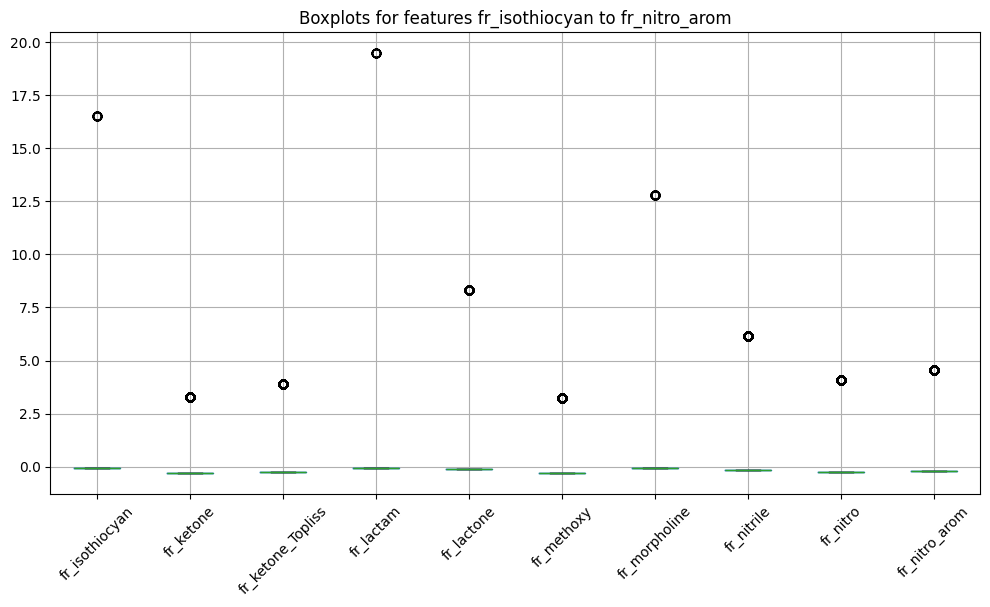

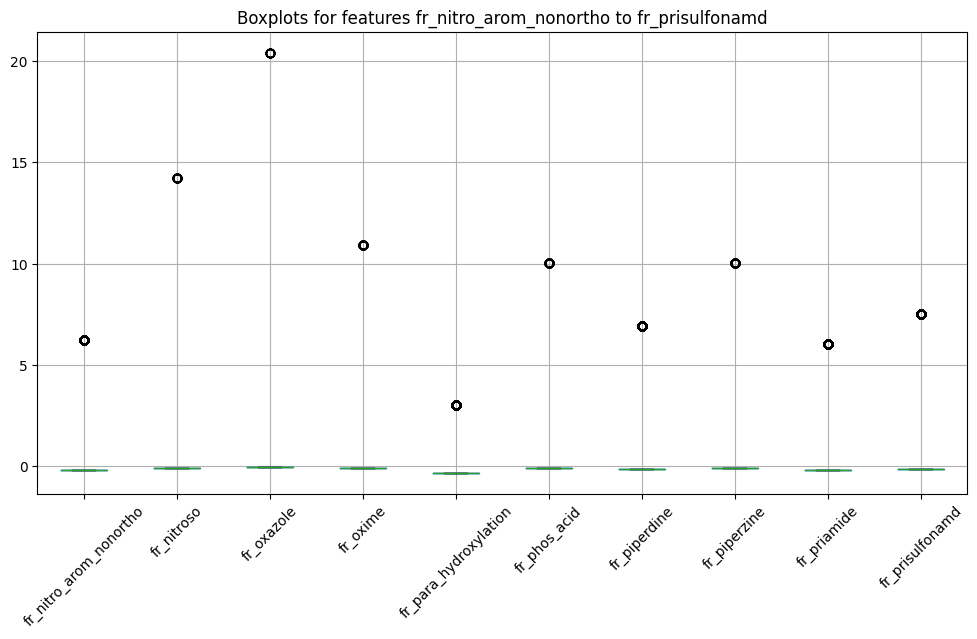

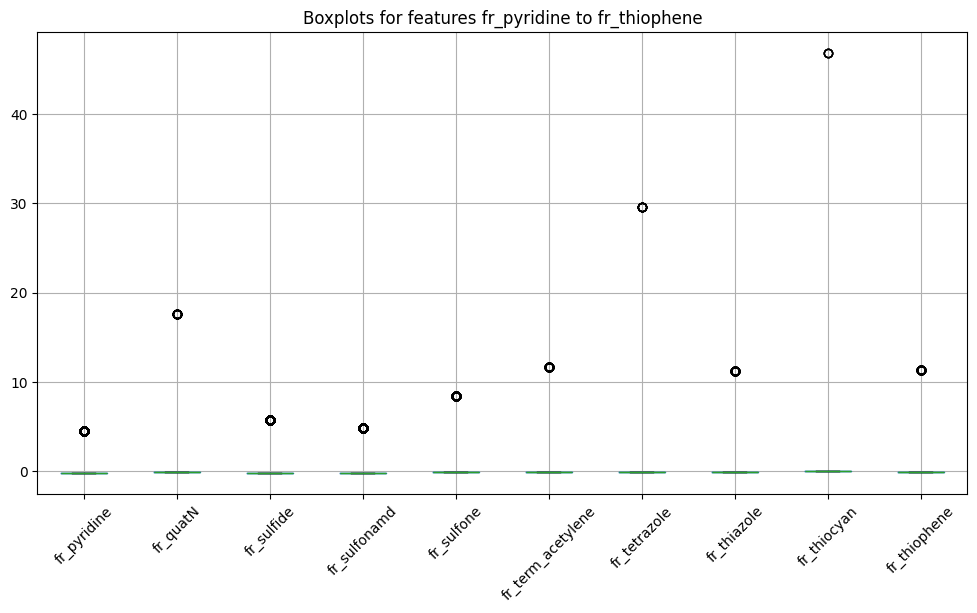

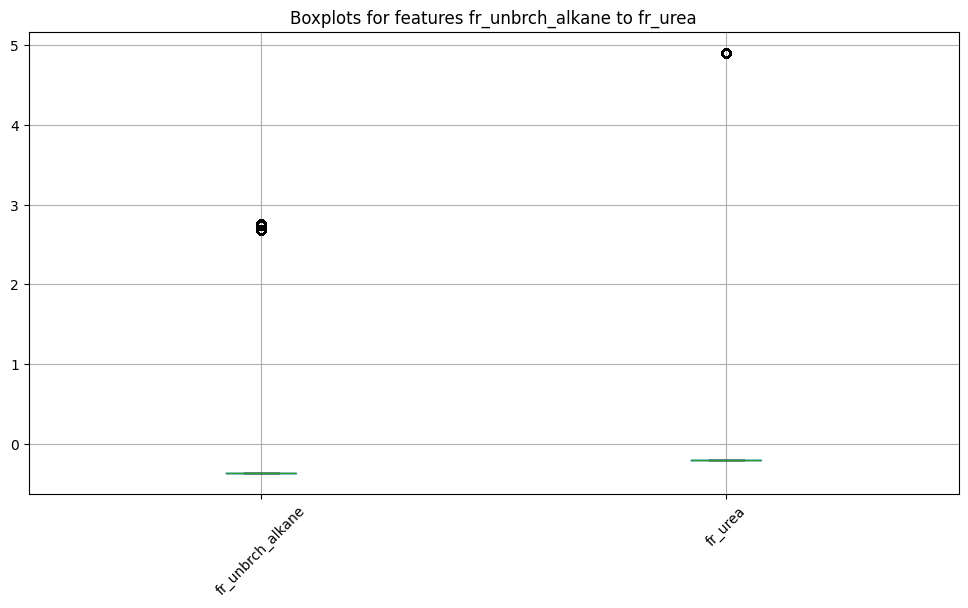

In [43]:
feature_groups = [X_trans_df.columns[i:i+10] for i in range(0, len(X_trans_df.columns), 10)]

for i, group in enumerate(feature_groups, 1):
    plt.figure(figsize=(12,6))
    X_trans_df[group].boxplot()
    plt.title(f'Boxplots for features {group[0]} to {group[-1]}')
    plt.xticks(rotation=45)
    plt.show()

In [47]:
X_trans_df["NumRadicalElectrons"].sort_values(ascending=False)[:25]

811     38.201222
417     38.201222
68      38.201222
282     38.201222
170     38.201222
548     38.201222
6       -0.026177
7       -0.026177
8       -0.026177
9       -0.026177
8730    -0.026177
25      -0.026177
8746    -0.026177
8745    -0.026177
10      -0.026177
8761    -0.026177
4       -0.026177
8747    -0.026177
8748    -0.026177
8749    -0.026177
8750    -0.026177
8751    -0.026177
8752    -0.026177
8753    -0.026177
8754    -0.026177
Name: NumRadicalElectrons, dtype: float64

In [ ]:
df.iloc[[811, 417, 68, 282, 170, 548]]["NumRadicalElectrons"]

np.int64(6)

In [38]:
X_trans_df.iloc[197]["avg_atomic_charge_quadrupole_interaction"]

np.float64(0.03978314893846413)

In [40]:
df.iloc[8658]["smiles"]

'[O:1]([O:2][H:4])[H:3]'

In [ ]:
'[O:1]([O:2][H:4])[H:3]'